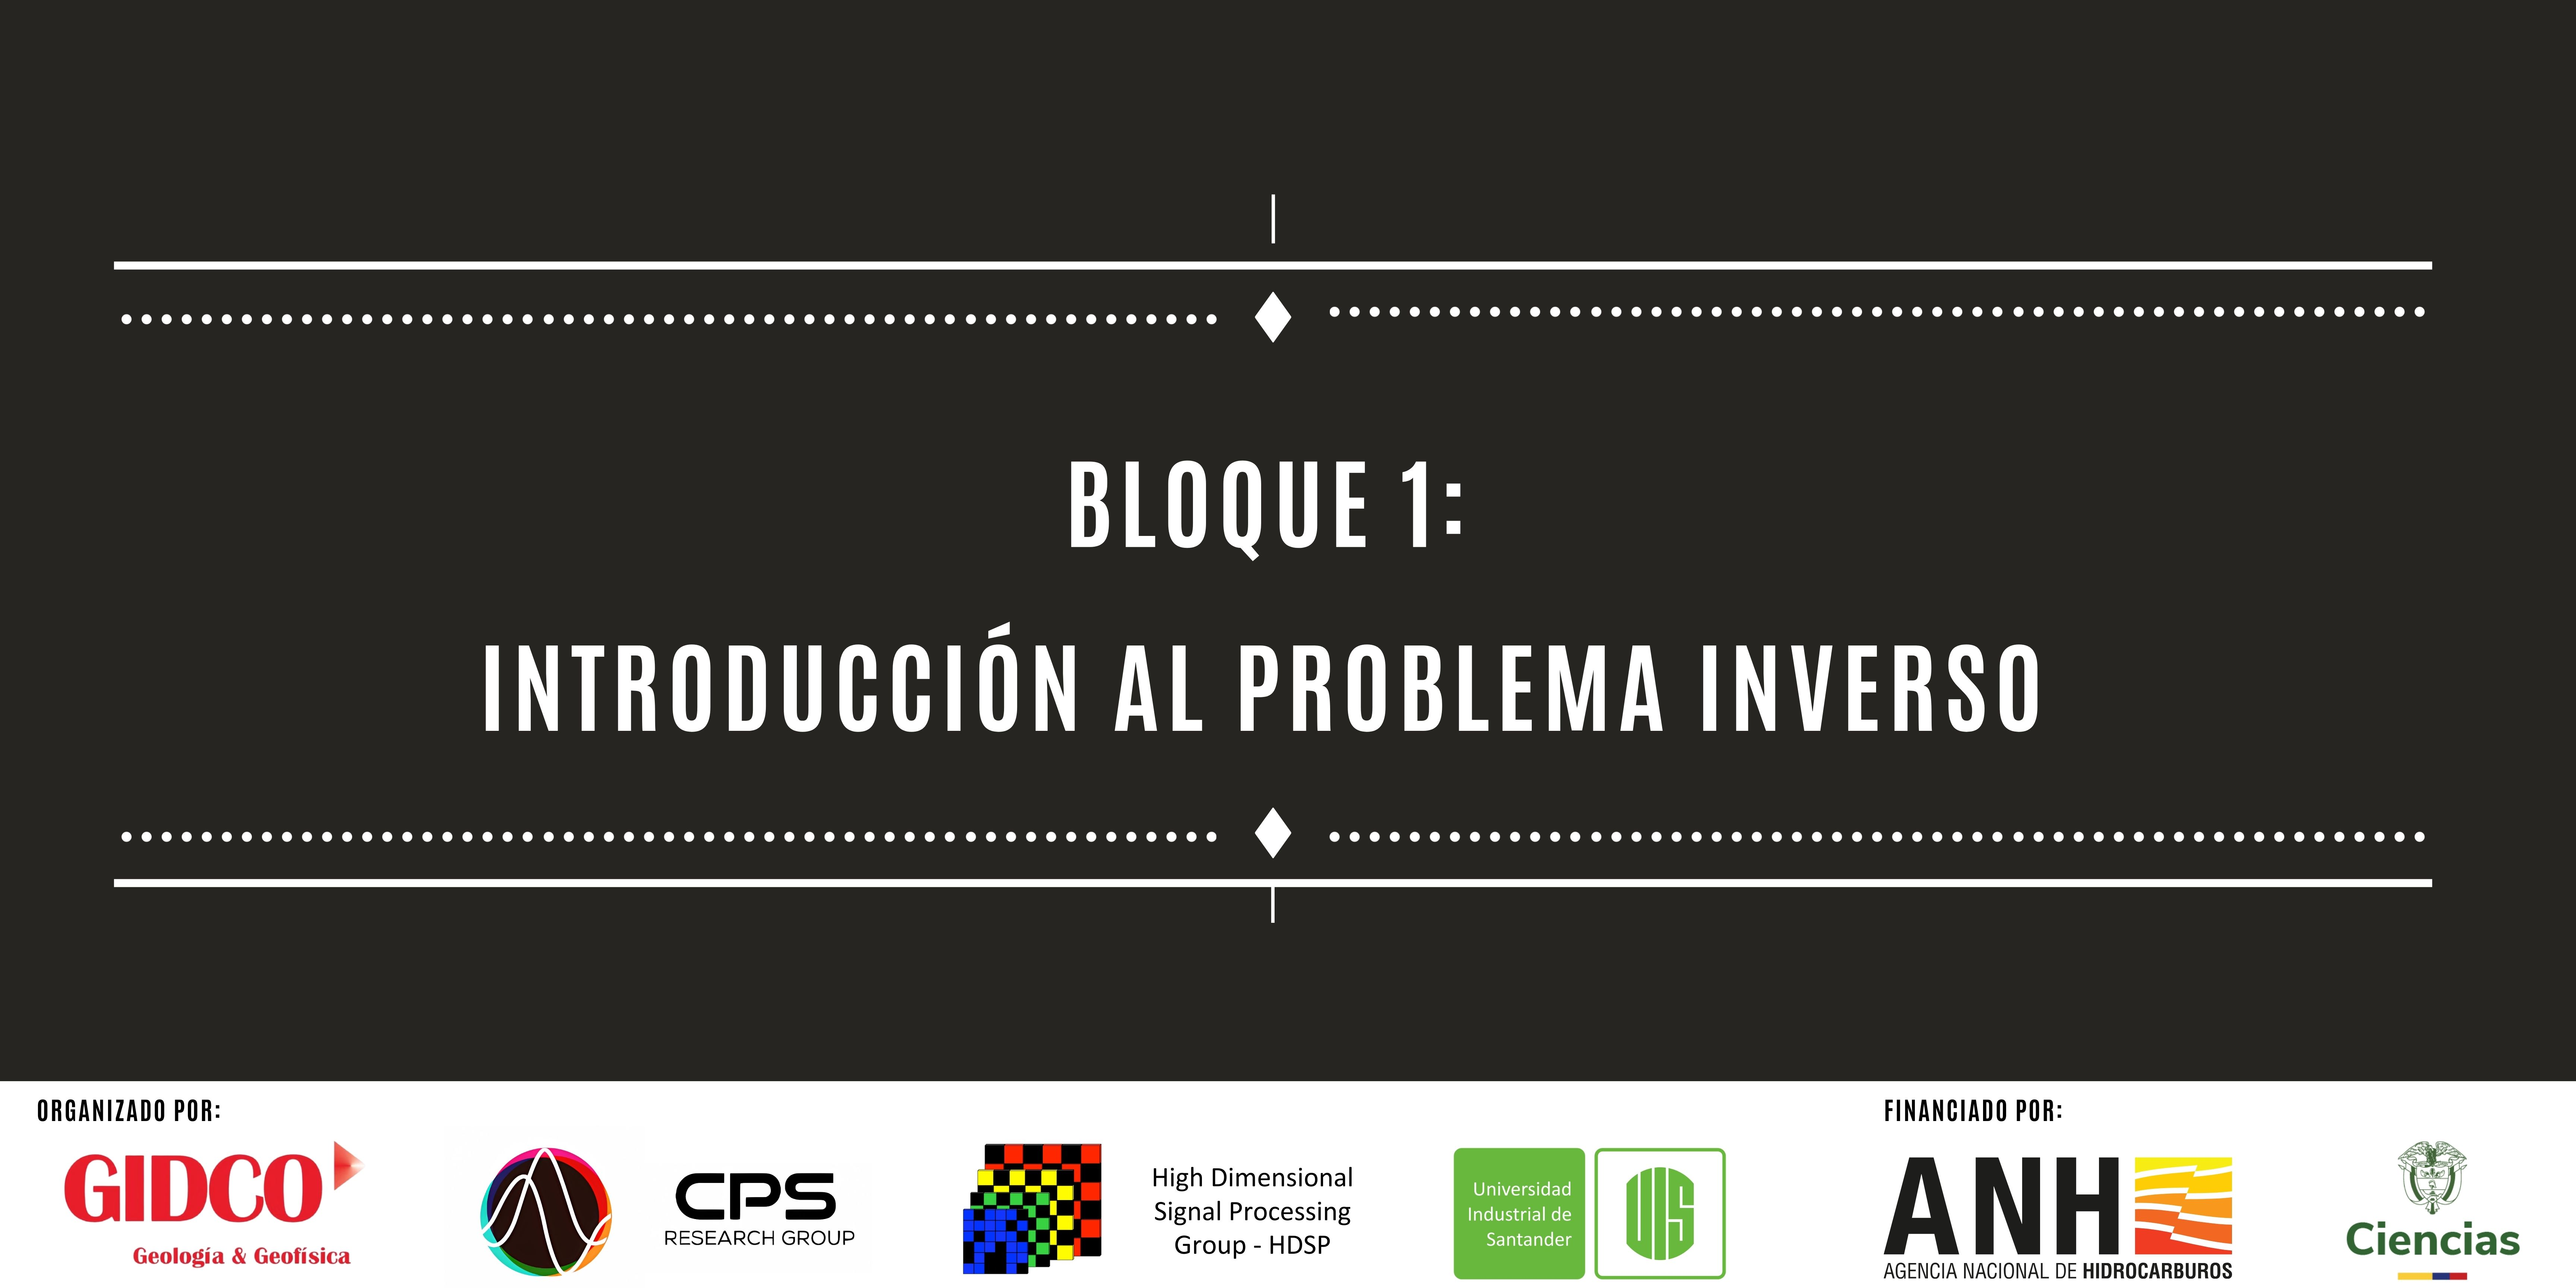

# Regresión lineal como problema inverso lineal: $F(\mathbf{m})=\mathbf{d}$

## Objetivo

En este cuaderno se estudia el ajuste de una recta como un **problema inverso lineal**, resuelto mediante un **esquema iterativo**.

La recta buscada es:

$$
y(x)=a\,x+b
$$

donde los parámetros desconocidos son:

$$
\mathbf{m}=
\begin{bmatrix}
a\\
b
\end{bmatrix}
$$

Si se tienen observaciones $(x_i,y_i)$, la relación entre el modelo y los datos puede escribirse como:

$$
\mathbf{d}_{pred}=F\mathbf{m}
$$

con:

$$
F=
\begin{bmatrix}
x_1 & 1\\
x_2 & 1\\
\vdots & \vdots\\
x_N & 1
\end{bmatrix}
$$

En la práctica, los datos observados contienen ruido, por lo que:

$$
\mathbf{d}_{obs}=\mathbf{d}_{pred}+\boldsymbol{\epsilon}
$$

El objetivo de la inversión es estimar el modelo $\mathbf{m}$ a partir de los datos observados, minimizando iterativamente el desajuste entre los datos predichos y los observados.

In [ ]:
#@title 1) Imports

import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1) Generación de datos sintéticos

En este bloque se construye un experimento controlado.

1. Se generan los valores de $x$.
2. Se define una recta verdadera.
3. Se añaden perturbaciones aleatorias para simular ruido.

La recta verdadera es:

$$
y_{true}(x)=a_{true}x+b_{true}
$$

y los datos observados se construyen como:

$$
y_{obs}=y_{true}+\epsilon
$$

donde $\epsilon$ representa ruido gaussiano.

In [ ]:
#@title Crear datos sintéticos

N = 25  #@param {type:"integer", min:2, max:500, step:1}
noise_sigma = 0.5  #@param {type:"number", min:0.0, max:10.0, step:0.1}

a_true = 2.0  #@param {type:"number", min:-10.0, max:10.0, step:0.1}
b_true = 1.0  #@param {type:"number", min:-10.0, max:10.0, step:0.1}

x_min = 0.0  #@param {type:"number", min:-1000.0, max:1000.0, step:0.5}
x_max = 10.0  #@param {type:"number", min:-1000.0, max:1000.0, step:0.5}

sampling = "linspace"  #@param ["linspace", "uniform_random"]
seed = 7  #@param {type:"integer", min:0, max:9999, step:1}

if x_max == x_min:
    x_max = x_min + 1.0

np.random.seed(seed)

if sampling == "linspace":
    x = np.linspace(x_min, x_max, N)
else:
    x = np.random.uniform(min(x_min, x_max), max(x_min, x_max), N)
    x = np.sort(x)

y_true = a_true * x + b_true
noise = np.random.normal(0.0, noise_sigma, N)
y_obs = y_true + noise

print(f"N = {N}")
print(f"Ruido sigma = {noise_sigma}")
print(f"Modelo verdadero: a = {a_true}, b = {b_true}")

N = 25
Ruido sigma = 0.5
Modelo verdadero: a = 2.0, b = 1.0


## 2) Visualización de los datos

Aquí se muestran:

- los **datos observados** con ruido;
- la **recta verdadera** usada para generar el experimento.

Este es el punto de partida del problema inverso: solo se observan datos, y a partir de ellos se quiere recuperar el modelo.

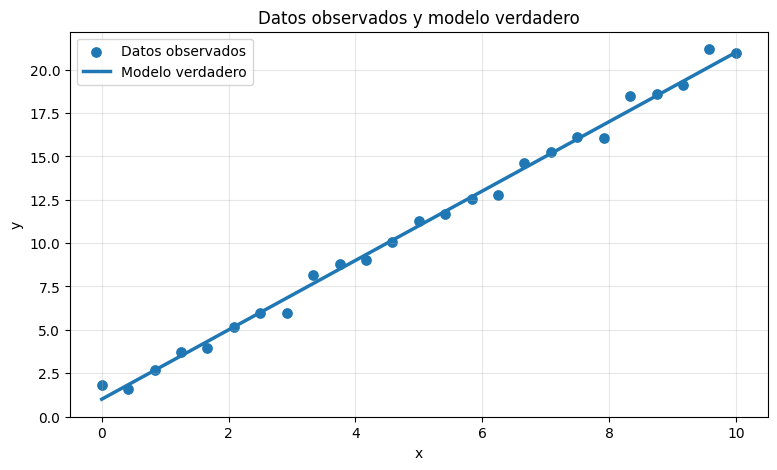

In [ ]:
#@title Gráfico de datos observados

x_line = np.linspace(np.min(x), np.max(x), 300)
y_line_true = a_true * x_line + b_true

plt.figure()
plt.scatter(x, y_obs, s=45, label="Datos observados")
plt.plot(x_line, y_line_true, linewidth=2.5, label="Modelo verdadero")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos observados y modelo verdadero")
plt.legend()
plt.show()

## 3) Formulación matricial del problema inverso

La ecuación de la recta:

$$
y_i=ax_i+b
$$

puede escribirse para todos los datos como:

$$
\mathbf{d}_{pred}=F\mathbf{m}
$$

donde:

$$
\mathbf{m}=
\begin{bmatrix}
a\\
b
\end{bmatrix}
$$

y

$$
F=
\begin{bmatrix}
x_1 & 1\\
x_2 & 1\\
\vdots & \vdots\\
x_N & 1
\end{bmatrix}
$$

En esta formulación:

- $\mathbf{m}$ es el **modelo**;
- $\mathbf{d}$ es el **vector de datos observados**;
- $F$ es el **operador directo** que relaciona el modelo con los datos predichos.

In [ ]:
#@title Construcción de F, m y d

show_F = False  #@param {type:"boolean"}

d = y_obs.reshape(-1, 1)

F = np.column_stack([x, np.ones_like(x)])

m_true = np.array([[a_true],
                   [b_true]], dtype=float)

d_true_from_Fm = F @ m_true

print("Dimensiones:")
print(f"F: {F.shape}")
print(f"m_true: {m_true.shape}")
print(f"d: {d.shape}")

if show_F:
    print("\nPrimeras filas de F:")
    print(F[:min(10, N), :])

Dimensiones:
F: (25, 2)
m_true: (2, 1)
d: (25, 1)


## 4) Solución iterativa por descenso de gradiente

El problema inverso se resuelve minimizando una función costo que mide el desajuste entre los datos predichos y los datos observados.

### Función objetivo

Se define la función costo como:

$$
J(\mathbf{m})=\frac{1}{2N}\|F\mathbf{m}-\mathbf{d}_{obs}\|_2^2
$$

Esta función mide qué tan lejos están los datos calculados por el modelo respecto a los datos observados.

### Gradiente

Para este problema lineal, el gradiente de la función costo es:

$$
\nabla J(\mathbf{m})=\frac{1}{N}F^T(F\mathbf{m}-\mathbf{d}_{obs})
$$

### Regla de actualización iterativa

El modelo se actualiza en cada iteración mediante:

$$
\mathbf{m}^{(k+1)}=\mathbf{m}^{(k)}-\alpha \nabla J(\mathbf{m}^{(k)})
$$

donde:

- $\mathbf{m}^{(k)}$ es el modelo en la iteración $k$;
- $\alpha$ es la tasa de aprendizaje;
- $\nabla J(\mathbf{m}^{(k)})$ indica la dirección de mayor aumento de la función costo.

Como se resta el gradiente, el modelo se mueve en la dirección que reduce progresivamente el error.

In [ ]:
#@title Definir funciones para descenso de gradiente

def cost_function(F, m, d):
    """
    Calcula la función costo:

    J(m) = 1/(2N) ||F m - d||²
    """
    r = F @ m - d
    return 0.5 * np.mean(r**2)


def gradient_function(F, m, d):
    """
    Calcula el gradiente de la función costo:

    grad J(m) = 1/N Fᵀ(Fm - d)
    """
    r = F @ m - d
    return (F.T @ r) / F.shape[0]

## 5) Ejecución del esquema iterativo

En este bloque se ejecuta el descenso de gradiente.

El proceso parte de un modelo inicial:

$$
\mathbf{m}^{(0)}=
\begin{bmatrix}
a^{(0)}\\
b^{(0)}
\end{bmatrix}
$$

y lo actualiza iterativamente hasta obtener un modelo que reduzca el valor de la función costo.

In [ ]:
#@title Ejecutar descenso de gradiente

gd_init_a = 0.0  #@param {type:"number", min:-20.0, max:20.0, step:0.1}
gd_init_b = 0.0  #@param {type:"number", min:-20.0, max:20.0, step:0.1}

gd_iterations = 500  #@param {type:"integer", min:1, max:20000, step:1}

gd_lr_mode = "auto"  #@param ["auto", "manual"]
gd_lr_manual = 0.01  #@param {type:"number", min:0.000001, max:10.0, step:0.000001}
gd_auto_lr_factor = 0.90  #@param {type:"number", min:0.01, max:1.99, step:0.01}

# Matriz asociada al problema cuadrático
H = (F.T @ F) / F.shape[0]

# Valor máximo propio usado para estimar una tasa de aprendizaje estable
L = float(np.max(np.linalg.eigvalsh(H)))

if gd_lr_mode == "auto":
    alpha = gd_auto_lr_factor / max(L, 1e-12)
else:
    alpha = gd_lr_manual

# Modelo inicial
m_gd = np.array([[gd_init_a],
                 [gd_init_b]], dtype=float)

# Historial del proceso iterativo
J_history = [float(cost_function(F, m_gd, d))]
a_history = [float(m_gd[0, 0])]
b_history = [float(m_gd[1, 0])]

# Iteraciones del descenso de gradiente
for k in trange(gd_iterations, desc="Descenso de gradiente"):

    grad = gradient_function(F, m_gd, d)

    m_gd = m_gd - alpha * grad

    J_history.append(float(cost_function(F, m_gd, d)))
    a_history.append(float(m_gd[0, 0]))
    b_history.append(float(m_gd[1, 0]))

# Modelo final
a_gd = float(m_gd[0, 0])
b_gd = float(m_gd[1, 0])

# Datos predichos con el modelo final
d_pred_gd = F @ m_gd

# Residuos
r_gd = d - d_pred_gd

# Error cuadrático medio
rmse_gd = float(np.sqrt(np.mean(r_gd**2)))

print("Resultado final del esquema iterativo")
print("-" * 50)
print(f"alpha = {alpha:.6e}")
print(f"a_gd = {a_gd:.6f}")
print(f"b_gd = {b_gd:.6f}")
print(f"RMSE = {rmse_gd:.6f}")
print(f"Costo final = {cost_function(F, m_gd, d):.6e}")

Descenso de gradiente: 100%|██████████| 500/500 [00:00<00:00, 24247.90it/s]

Resultado final del esquema iterativo
--------------------------------------------------
alpha = 2.588578e-02
a_gd = 2.015018
b_gd = 0.945457
RMSE = 0.456307
Costo final = 1.041079e-01


## 6) Evolución de la función costo

Este gráfico muestra cómo cambia:

$$
J(\mathbf{m}^{(k)})
$$

a medida que avanzan las iteraciones.

Si el algoritmo funciona correctamente, la función costo debe disminuir progresivamente.

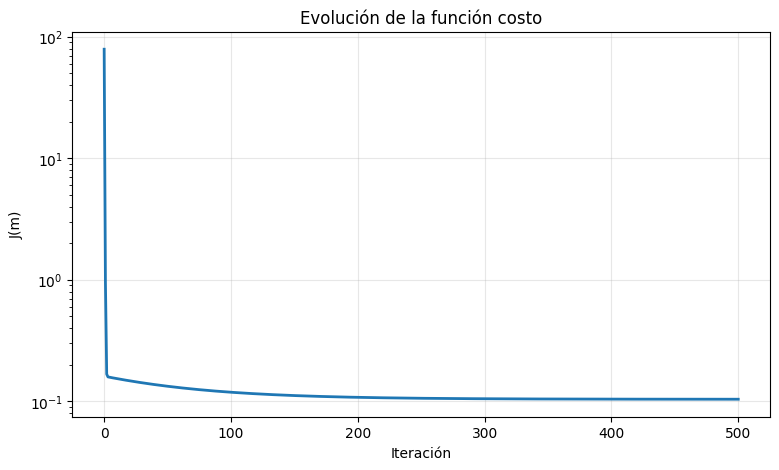

In [ ]:
#@title Historia de la función costo

plt.figure()
plt.plot(J_history, linewidth=2)
plt.yscale("log")
plt.xlabel("Iteración")
plt.ylabel("J(m)")
plt.title("Evolución de la función costo")
plt.show()

## 7) Evolución de los parámetros del modelo

En este gráfico se observa cómo cambian los parámetros estimados $a$ y $b$ durante el proceso iterativo.

Esto permite visualizar cómo el modelo se va ajustando desde el valor inicial hasta una solución final.

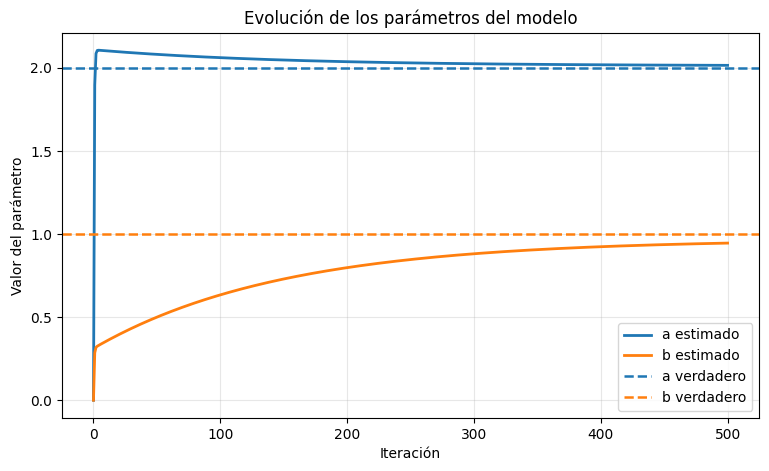

In [ ]:
#@title Evolución de los parámetros a y b

plt.figure()

plt.plot(a_history, linewidth=2, color="tab:blue", label="a estimado")
plt.plot(b_history, linewidth=2, color="tab:orange", label="b estimado")

plt.axhline(a_true, linestyle="--", linewidth=1.8, color="tab:blue", label="a verdadero")
plt.axhline(b_true, linestyle="--", linewidth=1.8, color="tab:orange", label="b verdadero")

plt.xlabel("Iteración")
plt.ylabel("Valor del parámetro")
plt.title("Evolución de los parámetros del modelo")
plt.legend()
plt.show()

## 8) Ajuste obtenido por el esquema iterativo

Aquí se muestra la recta obtenida después del proceso iterativo.

La comparación visual permite analizar si el descenso de gradiente logró reconstruir una solución razonable a partir del modelo inicial escogido.

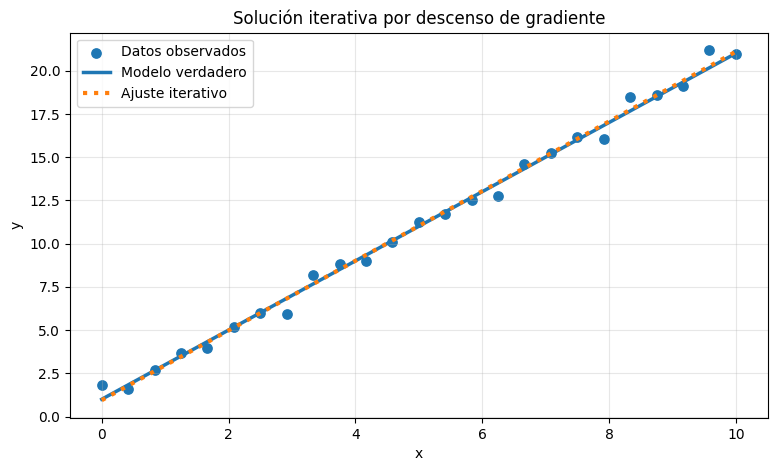

In [ ]:
#@title Gráfico del ajuste por descenso de gradiente

y_line_gd = a_gd * x_line + b_gd

plt.figure()
plt.scatter(x, y_obs, s=45, label="Datos observados")
plt.plot(x_line, y_line_true, linewidth=2.5, label="Modelo verdadero")
plt.plot(x_line, y_line_gd, ":", linewidth=3.0, label="Ajuste iterativo")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Solución iterativa por descenso de gradiente")
plt.legend()
plt.show()

## 9) Residuos del modelo final

Los residuos se definen como:

$$
\mathbf{r}=\mathbf{d}_{obs}-\mathbf{d}_{pred}
$$

Este gráfico permite ver cuánto se desvía la predicción respecto a los datos observados en cada punto.

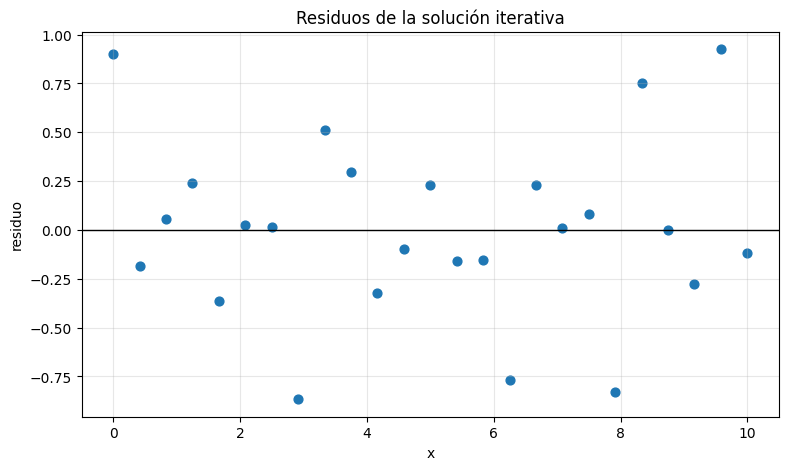

In [ ]:
#@title Residuos del modelo iterativo

plt.figure()
plt.axhline(0.0, color="k", linewidth=1)
plt.scatter(x, r_gd.flatten(), s=40)
plt.xlabel("x")
plt.ylabel("residuo")
plt.title("Residuos de la solución iterativa")
plt.show()

## 10) Resumen numérico final

Este bloque resume los valores estimados de los parámetros y la calidad del ajuste obtenido mediante el esquema iterativo.

In [ ]:
#@title Resumen numérico final

print("Resumen del modelo")
print("-" * 55)
print(f"{'Parámetro':<15}{'Verdadero':>15}{'Estimado GD':>15}")
print("-" * 55)
print(f"{'a':<15}{a_true:>15.6f}{a_gd:>15.6f}")
print(f"{'b':<15}{b_true:>15.6f}{b_gd:>15.6f}")
print("-" * 55)

print("\nResumen de ajuste")
print("-" * 55)
print(f"{'Métrica':<25}{'Valor':>20}")
print("-" * 55)
print(f"{'RMSE':<25}{rmse_gd:>20.6e}")
print(f"{'Costo final':<25}{cost_function(F, m_gd, d):>20.6e}")
print("-" * 55)

Resumen del modelo
-------------------------------------------------------
Parámetro            Verdadero    Estimado GD
-------------------------------------------------------
a                     2.000000       2.015018
b                     1.000000       0.945457
-------------------------------------------------------

Resumen de ajuste
-------------------------------------------------------
Métrica                                 Valor
-------------------------------------------------------
RMSE                             4.563067e-01
Costo final                      1.041079e-01
-------------------------------------------------------


## 11) Preguntas de exploración

### Sobre los datos

- ¿Qué ocurre al aumentar `noise_sigma`?
- ¿Qué pasa cuando se aumenta `N`?

### Sobre el esquema iterativo

- ¿Qué ocurre si el modelo inicial está lejos del modelo verdadero?
- ¿Qué pasa si el número de iteraciones es muy pequeño?
- ¿Qué ocurre si la tasa de aprendizaje es demasiado pequeña?
- ¿Qué ocurre si la tasa de aprendizaje es demasiado grande?

### Sobre la inversión

- ¿Cómo se interpreta el operador directo $F$?
- ¿Qué representa el modelo $\mathbf{m}$?
- ¿Qué relación existe entre los residuos y la calidad del ajuste?
- ¿Por qué el descenso de gradiente puede usarse para resolver problemas inversos?